# Accidental Data Leakage Demo

This notebook demonstrates how an employee can accidentally expose confidential data by pasting internal material into an AI tool.

The workflow includes:
- a fake internal dataset with customers, invoices, confidential project notes, meeting notes, and fake API keys
- a local SQLite database that stores both the source data and the AI-tool retention artifacts
- a simulated prompt submission that leaks sensitive information into chat logs, browser history, telemetry, vendor logs, and optional conversation memory
- outputs you can screenshot for your paper


In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
from IPython.display import Markdown, display

from accidental_data_leakage_demo import (
    RISK_STATEMENT,
    build_leaky_prompt,
    build_storage_summary,
    fetch_session_artifacts,
    initialize_demo_database,
    load_source_tables,
    render_flow_diagram,
    seed_demo_database,
    simulate_accidental_leakage,
)


## Database Setup

This cell creates the SQLite database file under `data/` and seeds the fake internal records.


In [2]:
DB_PATH = Path("data/accidental_data_leakage_demo.db")
MEMORY_ENABLED = True
VENDOR_LOGGING_ENABLED = True
TOOL_NAME = "Internal Productivity Copilot"

initialize_demo_database(DB_PATH)
seed_counts = seed_demo_database(DB_PATH)

pd.DataFrame(
    [{"table": name, "rows_seeded": count} for name, count in seed_counts.items()]
)


,table,rows_seeded
0,customers,2
1,invoices,2
2,project_notes,2
3,api_keys,2
4,meeting_notes,2


## Fake Internal Dataset

These are the internal records the employee should not paste into an external or semi-external AI workflow.


In [3]:
source_tables = load_source_tables(DB_PATH)

for table_name, frame in source_tables.items():
    display(Markdown(f"### {table_name.replace('_', ' ').title()}"))
    display(frame)


### Customers

,customer_id,company_name,contact_name,contact_email,plan_tier,renewal_date
0,CUST-1001,Northwind Surgical,Maya Patel,maya.patel@northwind.example,Enterprise,2026-05-15
1,CUST-1002,Lakeview Clinics,Ethan Ross,ethan.ross@lakeview.example,Business,2026-06-01


### Invoices

,invoice_id,customer_id,amount_due,currency,due_date,status,bank_reference
0,INV-1048,CUST-1001,48250.0,USD,2026-04-30,Overdue,ACCT-7781-FAKE
1,INV-1051,CUST-1002,19300.0,USD,2026-05-08,Open,ACCT-4419-FAKE


### Project Notes

,project_code,classification,owner,note_text
0,PRJ-AURORA-221,Confidential,Platform Security,Project Aurora is preparing a beta rollout tha...
1,PRJ-DELTA-118,Internal,Finance Systems,Delta will replace the legacy invoice approval...


### Api Keys

,system_name,environment,api_key,owner,rotation_due
0,claims-summarizer,staging,sk-demo-aurora-7F4X9Q2L8M1N,A. Chen,2026-05-01
1,billing-exporter,sandbox,sk-demo-billing-5Q1L2M8R4T7Z,K. Lewis,2026-05-10


### Meeting Notes

,meeting_id,meeting_date,attendees,note_text
0,MEET-302,2026-04-17,"Sales Ops, Finance, Customer Success",Finance approved a 12 percent discount for Nor...
1,MEET-304,2026-04-18,"Support, Platform Security",Do not share sandbox credentials in external s...


## Prompt That Causes the Leak

The employee is trying to get help writing a renewal summary, but the pasted prompt contains confidential data from several internal sources.


In [4]:
prompt, shared_items = build_leaky_prompt(DB_PATH)

display(Markdown("### Prompt pasted into the AI tool"))
print(prompt)

display(Markdown("### Sensitive data included in the prompt"))
shared_items


### Prompt pasted into the AI tool

Draft an executive update for tomorrow's renewal call and summarize the exposure risk.

Customer context:
- Customer ID: CUST-1001
- Company: Northwind Surgical
- Contact: Maya Patel
- Contact email: maya.patel@northwind.example
- Renewal date: 2026-05-15

Billing context:
- Invoice: INV-1048
- Amount due: USD 48,250.00
- Due date: 2026-04-30
- Bank reference: ACCT-7781-FAKE

Confidential project note:
- PRJ-AURORA-221 (Confidential): Project Aurora is preparing a beta rollout that migrates 8,400 patient claim records into the internal assistant sandbox.

Temporary API credential:
- claims-summarizer staging key: sk-demo-aurora-7F4X9Q2L8M1N

Meeting note:
- Finance approved a 12 percent discount for Northwind Surgical if the renewal closes before 2026-05-15. Keep the concession internal.

Please turn this into a concise customer-facing summary and tell me what issues stand out.


### Sensitive data included in the prompt

,source_table,source_reference,leaked_field,leaked_value,reason
0,customers,CUST-1001,contact_email,maya.patel@northwind.example,Personally identifying customer contact inform...
1,invoices,INV-1048,amount_due,"USD 48,250.00",Non-public financial balance and invoice refer...
2,project_notes,PRJ-AURORA-221,note_text,Project Aurora is preparing a beta rollout tha...,Confidential internal project details.
3,api_keys,claims-summarizer,api_key,sk-demo-aurora-7F4X9Q2L8M1N,Credential material that should never be paste...
4,meeting_notes,MEET-302,note_text,Finance approved a 12 percent discount for Nor...,Internal pricing strategy and discount concess...


## Run the Leakage Workflow

This simulates a user submitting the prompt to an internal chatbot with memory and vendor logging enabled.


In [5]:
result = simulate_accidental_leakage(
    DB_PATH,
    memory_enabled=MEMORY_ENABLED,
    vendor_logging_enabled=VENDOR_LOGGING_ENABLED,
    tool_name=TOOL_NAME,
)

session_id = result["session_id"]
print(f"Created demo session: {session_id}")
print(f"Sensitive matches detected in prompt: {result['prompt_summary']['total_matches']}")

pd.DataFrame(
    {
        "setting": ["memory_enabled", "vendor_logging_enabled"],
        "value": [MEMORY_ENABLED, VENDOR_LOGGING_ENABLED],
    }
)


Created demo session: session-20260418-113153
Sensitive matches detected in prompt: 5


,setting,value
0,memory_enabled,True
1,vendor_logging_enabled,True


## Where the Data Ended Up

These tables show the retained artifacts after the prompt was submitted.


In [6]:
artifacts = fetch_session_artifacts(DB_PATH, session_id)

for name, frame in artifacts.items():
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(frame)


### Chat Logs

,role,message_text,sensitive_matches_json,created_at
0,user,Draft an executive update for tomorrow's renew...,"{""total_matches"": 5, ""counts"": {""customer_id"":...",2026-04-18T15:31:53+00:00
1,assistant,"I drafted a summary for Northwind Surgical, re...","{""total_matches"": 1, ""counts"": {""invoice_id"": ...",2026-04-18T15:31:53+00:00


### Browser History

,page_title,url,snippet,stored_at
0,Internal Productivity Copilot Conversation,https://copilot.example.internal/chat/session-...,Draft an executive update for tomorrow's renew...,2026-04-18T15:31:53+00:00


### Telemetry Events

...

,provider_name,retention_policy,payload_excerpt,captured_at
0,External LLM Vendor,Retained for support and abuse monitoring in t...,Draft an executive update for tomorrow's renew...,2026-04-18T15:31:53+00:00


### Conversation Memory

,memory_key,memory_value,created_at
0,customer_context,Northwind Surgical has an enterprise renewal w...,2026-04-18T15:31:53+00:00
1,project_context,Project Aurora involves internal migration det...,2026-04-18T15:31:53+00:00
2,pricing_context,A 12 percent discount concession was discussed...,2026-04-18T15:31:53+00:00


### Prompt Leakage Items

,source_table,source_reference,leaked_field,leaked_value,reason
0,customers,CUST-1001,contact_email,maya.patel@northwind.example,Personally identifying customer contact inform...
1,invoices,INV-1048,amount_due,"USD 48,250.00",Non-public financial balance and invoice refer...
2,project_notes,PRJ-AURORA-221,note_text,Project Aurora is preparing a beta rollout tha...,Confidential internal project details.
3,api_keys,claims-summarizer,api_key,sk-demo-aurora-7F4X9Q2L8M1N,Credential material that should never be paste...
4,meeting_notes,MEET-302,note_text,Finance approved a 12 percent discount for Nor...,Internal pricing strategy and discount concess...


## Direct SQL Query

This cell connects to the SQLite database directly and queries the retained chat log records.


In [7]:
with sqlite3.connect(DB_PATH) as conn:
    sql_preview = pd.read_sql_query(
        """
        SELECT
            session_id,
            role,
            substr(message_text, 1, 120) AS preview,
            created_at
        FROM chat_logs
        ORDER BY id
        """,
        conn,
    )

sql_preview


,session_id,role,preview,created_at
0,session-20260418-113153,user,Draft an executive update for tomorrow's renew...,2026-04-18T15:31:53+00:00
1,session-20260418-113153,assistant,"I drafted a summary for Northwind Surgical, re...",2026-04-18T15:31:53+00:00


## Storage Summary

This table is useful for the write-up because it maps each storage location to the retained data and the risk.


In [8]:
build_storage_summary(DB_PATH, session_id)


,location,stored_data,why_it_exists,risk
0,Chat logs,Draft an executive update for tomorrow's renew...,Conversation history and support review.,Full prompt retention preserves all pasted con...
1,Browser history,Draft an executive update for tomorrow's renew...,"Session restore, autocomplete, and synced hist...",Prompt fragments can remain on the local devic...
2,Telemetry,"{""prompt_preview"": ""Draft an executive update ...","Analytics, debugging, and observability.",Prompt previews and sensitive counts leak into...
3,Vendor logs,Draft an executive update for tomorrow's renew...,External provider support and abuse monitoring.,Confidential prompts leave the company boundary.
4,Conversation memory,Northwind Surgical has an enterprise renewal w...,Future personalization and context reuse.,Sensitive facts can resurface in later prompts...


## Data Flow Diagram

User -> AI tool -> retained storage locations.


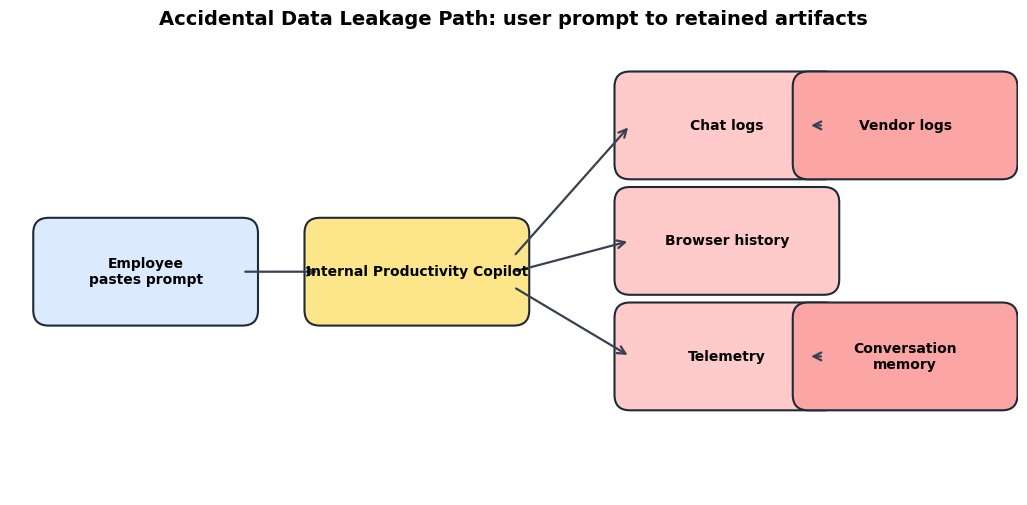

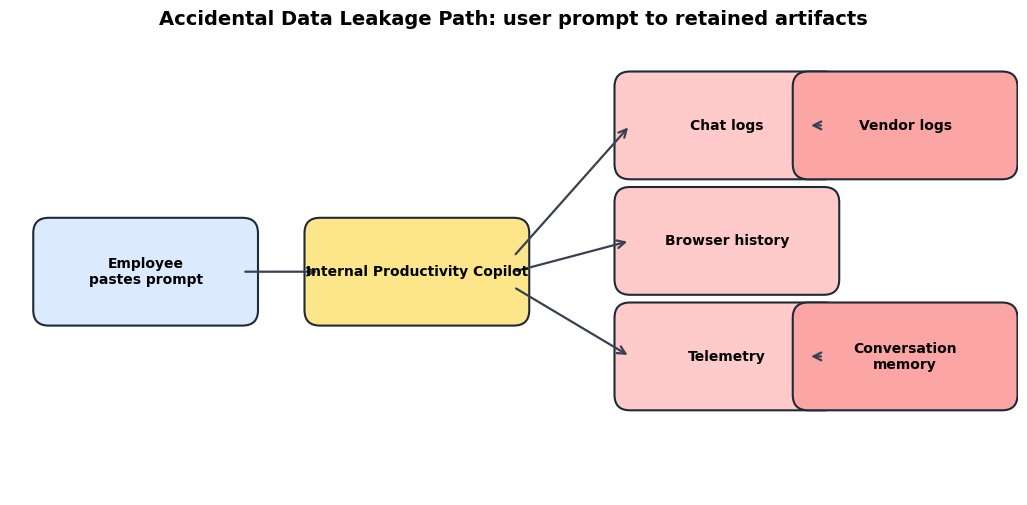

In [9]:
render_flow_diagram(
    tool_name=TOOL_NAME,
    memory_enabled=MEMORY_ENABLED,
    vendor_logging_enabled=VENDOR_LOGGING_ENABLED,
)


## Risk Statement

**Confidential data exposure via user prompts and retention.**

In this demo, the user copied confidential internal material into an AI workflow for convenience. The same content was then retained in the application chat log, browser history, telemetry data, vendor-side logging, and conversation memory. That creates multiple disclosure points even though the original user action was unintentional.
